# 统一诊断流水线示例（v2 盲梳检）

本 notebook 演示统一包 `bearing_unified` 的 v2 诊断流水线，两段式：

1. **仿真段**：用一条带已知答案的内圈故障仿真信号，逐步看清 v2 的每个环节——
   预处理 → Kurtogram 选带 → 零相位解调 → 包络谱 → 盲梳检（观测峰梳扫 +
   倒频谱互证）→ 干扰防护 → 频带落入定位 → 3 类置信度；
2. **真实数据段**：从现场音频资产库分层抽样逐条端到端诊断，并引用 1349 条
   正式验收的汇总数字。

核心思想一句话：**先在包络谱上盲检"有没有周期冲击族"（存在性，不依赖转速与
理论频率），存在之后才用轴承几何去"认领"周期（定位部位）。**

延伸阅读：`bearing_unified_method/docs/principles.md`（方法原理）与
`docs/design.md`（设计决策 D1–D22）。

## 0. 环境准备

无头 Agg 后端 + 中文字体（仓库统一约定）。

In [1]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.sans-serif"] = ["WenQuanYi Micro Hei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 100

from bearing_unified.fault_freqs import get_bearing
from bearing_unified.simulate import simulate
from bearing_unified.diagnose import diagnose
from bearing_unified.preprocessing import bandpass, clamp_band, detrend, remove_dc
from bearing_unified.kurtogram import kurtogram
from bearing_unified.spectrum import envelope_spectrum, real_cepstrum
from bearing_unified.combdet import (
    comb_match, comb_scan, cepstrum_confirm, mark_interference, pick_salient_peaks)
from bearing_unified.localize import class_bands, localize_comb

FS = 16000.0
F7 = get_bearing("FIELD7")   # 现场台架轴承：n=7, D=15.0, d=3.969, α=5.6°
print("FIELD7 特征频率 @1150rpm:", {k: round(v, 2) for k, v in F7.fault_frequencies(1150/60).items()})

FIELD7 特征频率 @1150rpm: {'BPFO': 49.42, 'BPFI': 84.75, 'BSF': 33.71, 'FTF': 7.06}


## 1. 仿真段：一条内圈故障信号的 v2 之旅

### 1.1 仿真信号

FIELD7 几何、1150 rpm、共振 2.2 kHz、SNR 5 dB、内圈故障（BPFI≈84.75 Hz）。

In [2]:
x, info = simulate("BPFI", fs=FS, duration=3.0, rpm=1150, bearing=F7,
                   snr_db=5, resonance_hz=2200, seed=42)
t = np.arange(x.size) / FS
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(t * 1000, x, lw=0.5, color="steelblue")
ax.set_xlabel("时间 (ms)"); ax.set_ylabel("加速度")
ax.set_title(f"仿真内圈故障信号（snr={info['snr_db']} dB, 共振={info['resonance_hz']:.0f} Hz）")
plt.show()
print("真实特征频率:", {k: round(v, 2) for k, v in info["true_fault_freqs"].items()})

真实特征频率: {'BPFO': 49.42, 'BPFI': 84.75, 'BSF': 33.71, 'FTF': 7.06}


/tmp/ipykernel_32236/3402966136.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### 1.2 预处理与 Kurtogram 选带

v2 的两条预处理路径（principles.md 第 6 章）：轻预处理（去直流/去趋势）供
Kurtogram 选带与解调；宽带零相位带通仅供转速自估与触发级特征。Kurtogram
在树状频带里找"包络峭度最高"的共振区——**选中的频带就是解调载波**。

In [3]:
x_dt = detrend(remove_dc(x))                     # 轻预处理
kg = kurtogram(x_dt, FS, max_level=4)
band = clamp_band(kg.best_band, FS)
print(f"Kurtogram 选中频带: ({band[0]:.0f}, {band[1]:.0f}) Hz, 包络峭度={kg.best_kurtosis:.1f}")

fig, ax = plt.subplots(figsize=(11, 3.2))
cmap = plt.get_cmap("viridis")
all_k = [k for row in kg.levels for (_, _, k) in row]
kmin, kmax = min(all_k), max(all_k)
for row in kg.levels:
    for (bl, bh, k) in row:
        ax.barh(bl, bh - bl, left=bl, height=0.7 * (bh - bl),
                color=cmap((k - kmin) / max(kmax - kmin, 1e-9)), alpha=0.85, edgecolor="none")
ax.barh(band[0], band[1] - band[0], left=band[0], height=0.7 * (band[1] - band[0]),
        fill=False, edgecolor="red", lw=2, label=f"选中频带（峭度 {kg.best_kurtosis:.1f}）")
ax.set_xlabel("频率 (Hz)"); ax.set_ylabel("频带下边界 (Hz)")
ax.set_title("Kurtogram：各频带包络峭度（颜色越亮冲击越强）"); ax.legend()
plt.show()

Kurtogram 选中频带: (667, 2000) Hz, 包络峭度=14.9


/tmp/ipykernel_32236/1318329641.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### 1.3 零相位解调与包络谱

零相位带通（sosfiltfilt，冲击时刻不偏移）→ Hilbert 包络 → 包络谱。
v2 的包络谱分析窗为 0–800 Hz（覆盖 150 Hz 基频的 5 次谐波）。

In [4]:
xb = bandpass(x_dt, FS, band[0], band[1])          # 零相位解调带通
env_f, env_a = envelope_spectrum(xb, FS, max_freq=800.0)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(env_f, env_a, lw=0.8, color="steelblue")
ax.set_xlabel("频率 (Hz)"); ax.set_ylabel("包络幅值")
ax.set_title(f"包络谱（解调频带 {band[0]:.0f}–{band[1]:.0f} Hz）")
for f in (info["true_fault_freqs"]["BPFI"], 2 * info["true_fault_freqs"]["BPFI"]):
    ax.axvline(f, color="red", ls="--", lw=1, alpha=0.7)
ax.text(info["true_fault_freqs"]["BPFI"], ax.get_ylim()[1] * 0.85, " BPFI=84.75", color="red")
plt.show()

/tmp/ipykernel_32236/424651988.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### 1.4 盲梳检第一步：观测峰拾取

**不查任何理论频率**，先在包络谱上找"显著峰"：局部极大值且峰幅值/局部邻域
中位数 ≥ 5（与 matcher 同一定义）。

In [5]:
peaks = pick_salient_peaks(env_f, env_a)
print("显著峰（频率 / 显著度）:", [(round(f, 1), round(p, 1)) for f, a, p in peaks])

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(env_f, env_a, lw=0.8, color="steelblue")
for f, a, p in peaks:
    ax.plot(f, a, "rv", ms=8)
ax.set_xlabel("频率 (Hz)"); ax.set_ylabel("包络幅值")
ax.set_title("观测峰拾取（红三角 = 显著峰，全部成为候选梳基频）")
plt.show()

显著峰（频率 / 显著度）: [(65.7, 24.7), (84.7, 42.0), (104.0, 26.9)]


/tmp/ipykernel_32236/3771982047.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### 1.5 盲梳检第二步：谐波族验证（梳扫）

每个显著峰都是候选基频 f0：验证 k·f0（k=2..5）谐波族（±2% 窗、突出度 ≥5、
w_k=1/k 加权得分），**命中 ≥2 且得分 ≥0.15 且最低命中 ≤2 次** 才成梳；
下探规则偏好"能解释最多显著峰的最小基频"（滚珠 2×BSF 主峰的基频归并）。

In [6]:
combs_a = comb_scan(env_f, env_a, dive_floor=18.333 - 2.0)
print(f"A 阶段确认梳 {len(combs_a)} 个：")
for c in combs_a:
    s, h, covered, ks = comb_match(env_f, env_a, c["f0"])
    print(f"  f0={c['f0']:.2f} Hz  得分={c['score']:.3f}  命中={c['hits']} (k={ks})"
          f"  峰位={[round(v, 1) for v in covered]}"
          + ("  [low_f0: 基频<20Hz，按干扰排除]" if c["low_f0"] else ""))

A 阶段确认梳 2 个：
  f0=84.67 Hz  得分=0.990  命中=5 (k=[1, 2, 3, 4, 5])  峰位=[84.7, 169.7, 254.3, 339.3, 424.0]
  f0=104.00 Hz  得分=0.557  命中=3 (k=[1, 4, 5])  峰位=[104.0, 424.0, 509.7]


### 1.6 盲梳检第三步：倒频谱互证

谱域的"均匀间隔族"可能是巧合；倒频谱把周期凝聚为 q=1/f0 的单峰——
两条独立证据通道同时成立才认"梳存在"。

In [7]:
cep_q, cep_v = real_cepstrum(xb, FS, max_quefrency=0.2)
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(cep_q * 1000, cep_v, lw=0.8, color="dimgray")
for c in combs_a:
    ok, hits = cepstrum_confirm(cep_q, cep_v, c["f0"])
    q0 = 1000.0 / c["f0"]
    ax.axvline(q0, color="red", ls="--", lw=1.2,
               label=f"q0=1/{c['f0']:.1f}Hz={q0:.1f}ms → 互证{'成立' if ok else '失败'}(命中{hits})")
    print(f"f0={c['f0']:.2f}: 倒谱互证={ok}（显著 rahmonic 数={hits}）")
ax.set_xlabel("倒频率 q (ms)"); ax.set_ylabel("倒谱幅值")
ax.set_title("倒频谱互证（红虚线 = 候选梳的 q0=1/f0）")
ax.legend(fontsize=9); ax.set_xlim(0, 120)
plt.show()

f0=84.67: 倒谱互证=True（显著 rahmonic 数=2）
f0=104.00: 倒谱互证=False（显著 rahmonic 数=0）


/tmp/ipykernel_32236/3280581160.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### 1.7 干扰防护演示：工频 50 Hz 梳

50 Hz 工频恰落在外圈频带（47.3–51.6 Hz）内，是经典误报源。v2 对
f0 ≈ k×fr_nominal 或 50.0 Hz 的梳打 `suspected_interference` 标记并排除
（仍记录）。下面对本信号人为叠加 50 Hz 周期冲击演示防护生效。

In [8]:
# 人为叠加 50 Hz 周期冲击（模拟工频入侵）
per = int(round(FS / 50.0))
x_bad = x.copy()
x_bad[::per] += 1.5
x_dt_bad = detrend(remove_dc(x_bad))
kg_bad = kurtogram(x_dt_bad, FS, max_level=4)
band_bad = clamp_band(kg_bad.best_band, FS)
xb_bad = bandpass(x_dt_bad, FS, band_bad[0], band_bad[1])
ef_bad, ea_bad = envelope_spectrum(xb_bad, FS, max_freq=800.0)
df_bad = float(ef_bad[1] - ef_bad[0])
combs_bad = comb_scan(ef_bad, ea_bad, dive_floor=18.333 - 2.0)
print("叠加 50 Hz 后的梳与防护判定：")
for c in combs_bad:
    reason = "低频梳(疑轴频族)" if c["low_f0"] else mark_interference(c["f0"], df_bad, fr_nominal=19.167)
    print(f"  f0={c['f0']:.2f} Hz  得分={c['score']:.3f}  → 防护标记: {reason or '（无，进入定位）'}")

叠加 50 Hz 后的梳与防护判定：
  f0=50.00 Hz  得分=1.000  → 防护标记: 工频50Hz


### 1.8 频带落入定位与 3 类置信度

定位频带由转速窗×几何现算（`class_bands`），四个频带互不重叠；梳基频落入
即粗定类，再经理论复核（±4%）给出该类置信度。空档梳走 fr_hyp 补救，仍无解
判「轴承-未定位」（单列，不强行归类）。

In [9]:
bands = class_bands(F7, (1100.0, 1200.0))
print("定位频带（FIELD7 @ 1100–1200 rpm 现算）：")
for b in bands:
    print(f"  {b['label']:16s}: [{b['lo']:6.2f}, {b['hi']:6.2f}] Hz")

loc = localize_comb(env_f, env_a, 84.67, F7)
print(f"\n84.67 Hz 梳定位: 落入={loc['band'] or '（空档）'}  类别={loc['cls']}  "
      f"fr_hyp={loc['fr_hyp'] * 60:.0f} rpm")
print("三类置信度:", {k: round(v, 3) for k, v in loc['confs'].items()})

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(env_f, env_a, lw=0.8, color="steelblue")
colors = {"滚珠(BSF基频带)": "#DD8452", "外圈(BPFO带)": "#C44E52",
          "滚珠(2×BSF主峰带)": "#DD8452", "内圈(BPFI带)": "#55A868"}
for b in bands:
    ax.axvspan(b["lo"], b["hi"], color=colors[b["label"]], alpha=0.15, label=b["label"])
ax.axvline(84.67, color="red", lw=1.5, label="梳基频 84.67 Hz")
ax.set_xlabel("频率 (Hz)"); ax.set_ylabel("包络幅值")
ax.set_title("包络谱 + 定位频带底纹（梳基频落入内圈 BPFI 带）")
ax.legend(fontsize=8, loc="upper right")
plt.show()

定位频带（FIELD7 @ 1100–1200 rpm 现算）：
  滚珠(BSF基频带)      : [ 32.24,  35.17] Hz
  外圈(BPFO带)       : [ 47.27,  51.57] Hz
  滚珠(2×BSF主峰带)    : [ 64.48,  70.34] Hz
  内圈(BPFI带)       : [ 81.06,  88.43] Hz

84.67 Hz 梳定位: 落入=内圈(BPFI带)  类别=inner  fr_hyp=1149 rpm
三类置信度: {'outer': 0.211, 'inner': 0.99, 'ball': 0.453}


/tmp/ipykernel_32236/2432812659.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### 1.9 一步到位：`diagnose()`

上述逐步操作就是 `diagnose()` 的内部流程。直接调用并查看文本报告的关键段。

In [10]:
res = diagnose(x, fs=FS, bearing=F7)
print(f"判决: {res.verdict}（{res.verdict_cn}）  置信度: {res.confidence:.2f}（{res.level}）")
print(f"三类置信度: 外圈={res.conf_outer:.3f} 内圈={res.conf_inner:.3f} 滚珠={res.conf_ball:.3f}")
print(f"梳确认: A={res.comb_confirmed} B={res.cepstrum_confirmed} 干扰={res.n_interference} 净={res.n_clean_combs}")
print(f"转速自估（仅记录）: {res.rpm_est:.0f} rpm（回退={res.rpm_fallback}）")
print("提示:")
for note in res.notes:
    print("  -", note)

判决: BPFI（内圈故障）  置信度: 0.99（明确）
三类置信度: 外圈=0.211 内圈=0.990 滚珠=0.453
梳确认: A=2 B=1 干扰=0 净=1
转速自估（仅记录）: 1160 rpm（回退=False）
提示:
  - 未提供健康基线：马氏辅助判据未启用，无梳样本按未检出处理（域内标定见 baseline.calibrate_oof）
  - 检出 1 个有效梳（84.7 Hz），定位为内圈（置信度 0.99），反演轴频 1149 rpm


## 2. 真实数据段：现场录音端到端验证

从现场音频资产库（1349 条，16 kHz）分层抽 6 条代表性样本逐条诊断
（选择口径：正常 2 条判正常、轴承 2 条定位正确、轴承-未定位 1 条、
摩擦 1 条经马氏辅助判据触发——样本取自统一包正式验收的 results.csv）。

In [11]:
import csv
from pathlib import Path

ROOT = Path("/home/dayin/git/bearing_detection_method")
MANI = ROOT / "analysis" / "reports" / "audio_assets" / "manifest.tsv"
UNI = ROOT / "analysis" / "reports" / "audio_assets" / "unified" / "results.csv"

mani = {r["id"]: r for r in csv.DictReader(open(MANI, encoding="utf-8"), delimiter="\t")}
uni_rows = list(csv.DictReader(open(UNI, encoding="utf-8")))

def pick(pred, subset, n=1, excl=()):
    out = []
    for r in uni_rows:
        if r["id"] in excl:
            continue
        if r["subset"] == subset and r["pred_fault_type"] == pred:
            out.append(r)
            if len(out) == n:
                return out
    return out

samples = (pick("正常", "正常", 2) + pick("轴承", "轴承", 2)
           + pick("轴承-未定位", "轴承", 1) + pick("摩擦", "摩擦", 1))
for r in samples:
    print(f"  {r['id']} 标注={r['subset']} 验收判决={r['pred_fault_type']}"
          f"（梳=[{r['comb_freqs']}]）")

  9913 标注=正常 验收判决=正常（梳=[]）
  10013 标注=正常 验收判决=正常（梳=[]）
  10801 标注=轴承 验收判决=轴承（梳=[68.16]）
  10880 标注=轴承 验收判决=轴承（梳=[79.35]）
  10098 标注=轴承 验收判决=轴承-未定位（梳=[22.19]）
  10165 标注=摩擦 验收判决=摩擦（梳=[]）


### 2.1 逐条诊断（四联图）

对每条样本重新跑 `diagnose()` 并生成四联诊断图（时域指标 / FFT+解调频带 /
Kurtogram / 包络谱+频带底纹+梳标注）。

真实数据的「摩擦」判决依赖马氏健康基线（无梳样本的辅助判据）。标定数据与阈值**直接取自正式验收产物**（`unified/results.csv` 中 566 条正常样本的特征 + `eval_detail.json` 的 p99 阈值），notebook 不重复计算——与验收报告完全同一口径。

In [12]:
import json

from bearing_unified.baseline import HealthBaseline

# 标定数据与阈值直接取自正式验收产物（与验收报告完全同一口径）
uni_rows_all = list(csv.DictReader(open(UNI, encoding="utf-8")))
norm_feats = [{"kurtosis": float(r["feat_kurtosis"]),
               "crest_factor": float(r["feat_crest_factor"]),
               "clearance_factor": float(r["feat_clearance_factor"])}
              for r in uni_rows_all if r["is_normal"] == "1"]
BL = HealthBaseline().fit(norm_feats)
detail_acc = json.loads((ROOT / "analysis" / "reports" / "audio_assets" / "unified" / "eval_detail.json").read_text(encoding="utf-8"))
THR = detail_acc["calibration"]["thresholds"]["p99"]
print(f"标定完成：{len(norm_feats)} 条正常样本（来自验收 results.csv），p99 阈值 = {THR:.3f}")

标定完成：566 条正常样本（来自验收 results.csv），p99 阈值 = 8.888



===== 9913 标注=正常（description=）=====
判决: 正常（未检出轴承故障特征）（normal）  置信度 0.00
三类置信度: 外圈=0.000 内圈=0.000 滚珠=0.000  梳确认 A/B/干扰/净 = 0/0/0/0
马氏距离: 5.9（阈值 8.9）→ 触发=False


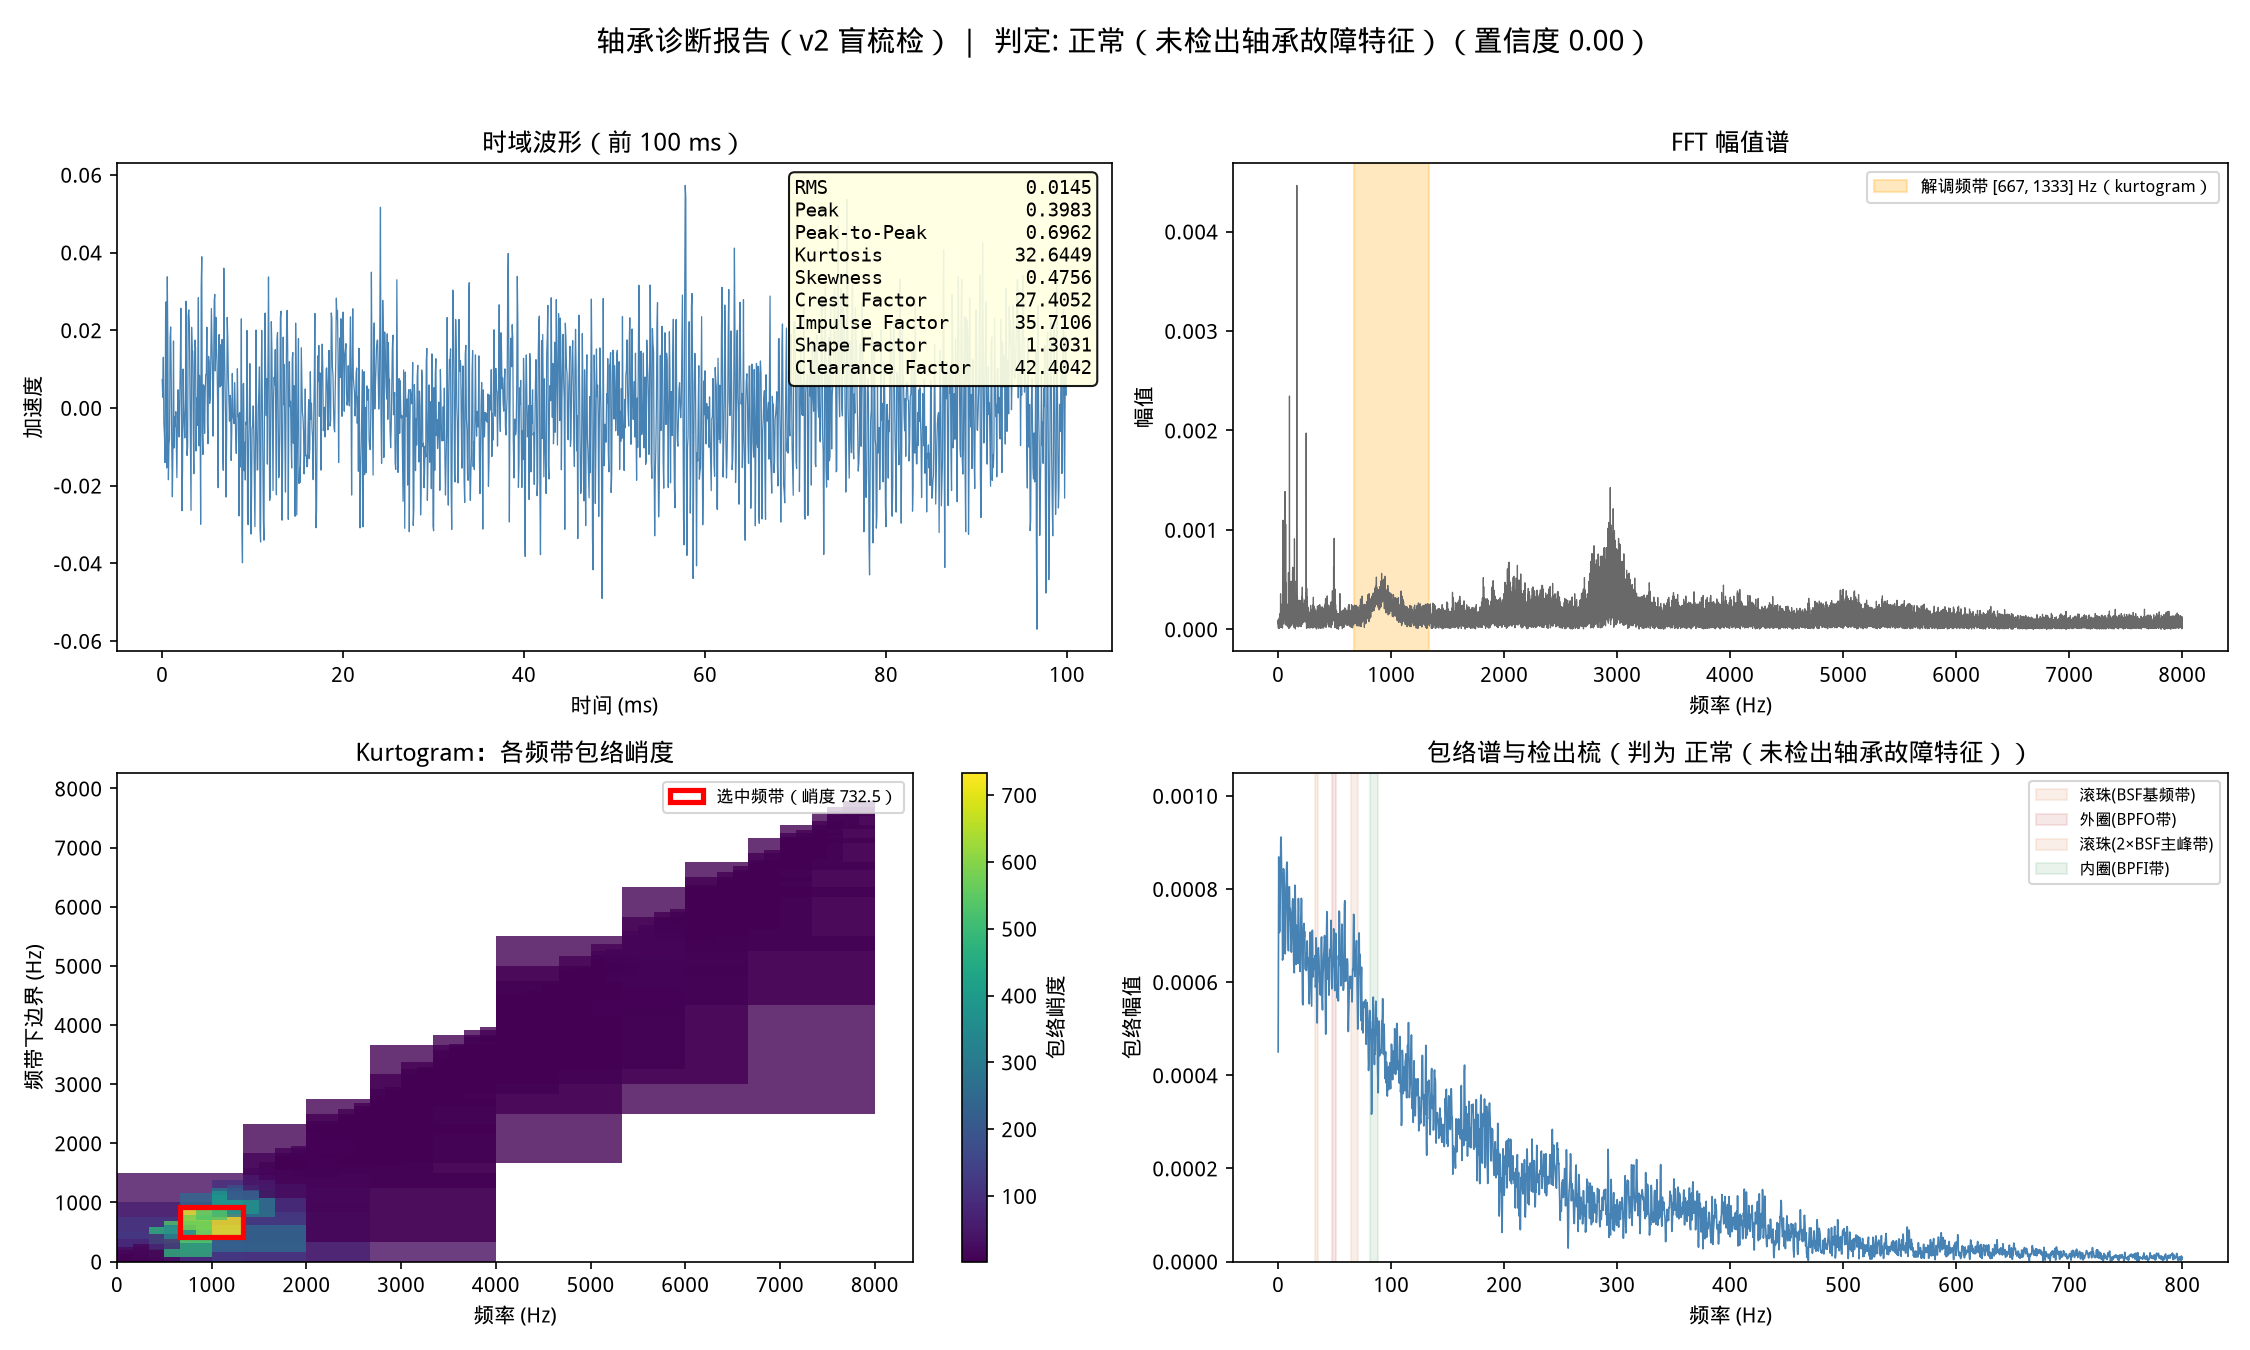


===== 10013 标注=正常（description=17）=====
判决: 正常（未检出轴承故障特征）（normal）  置信度 0.00
三类置信度: 外圈=0.000 内圈=0.000 滚珠=0.000  梳确认 A/B/干扰/净 = 0/0/0/0
马氏距离: 0.2（阈值 8.9）→ 触发=False


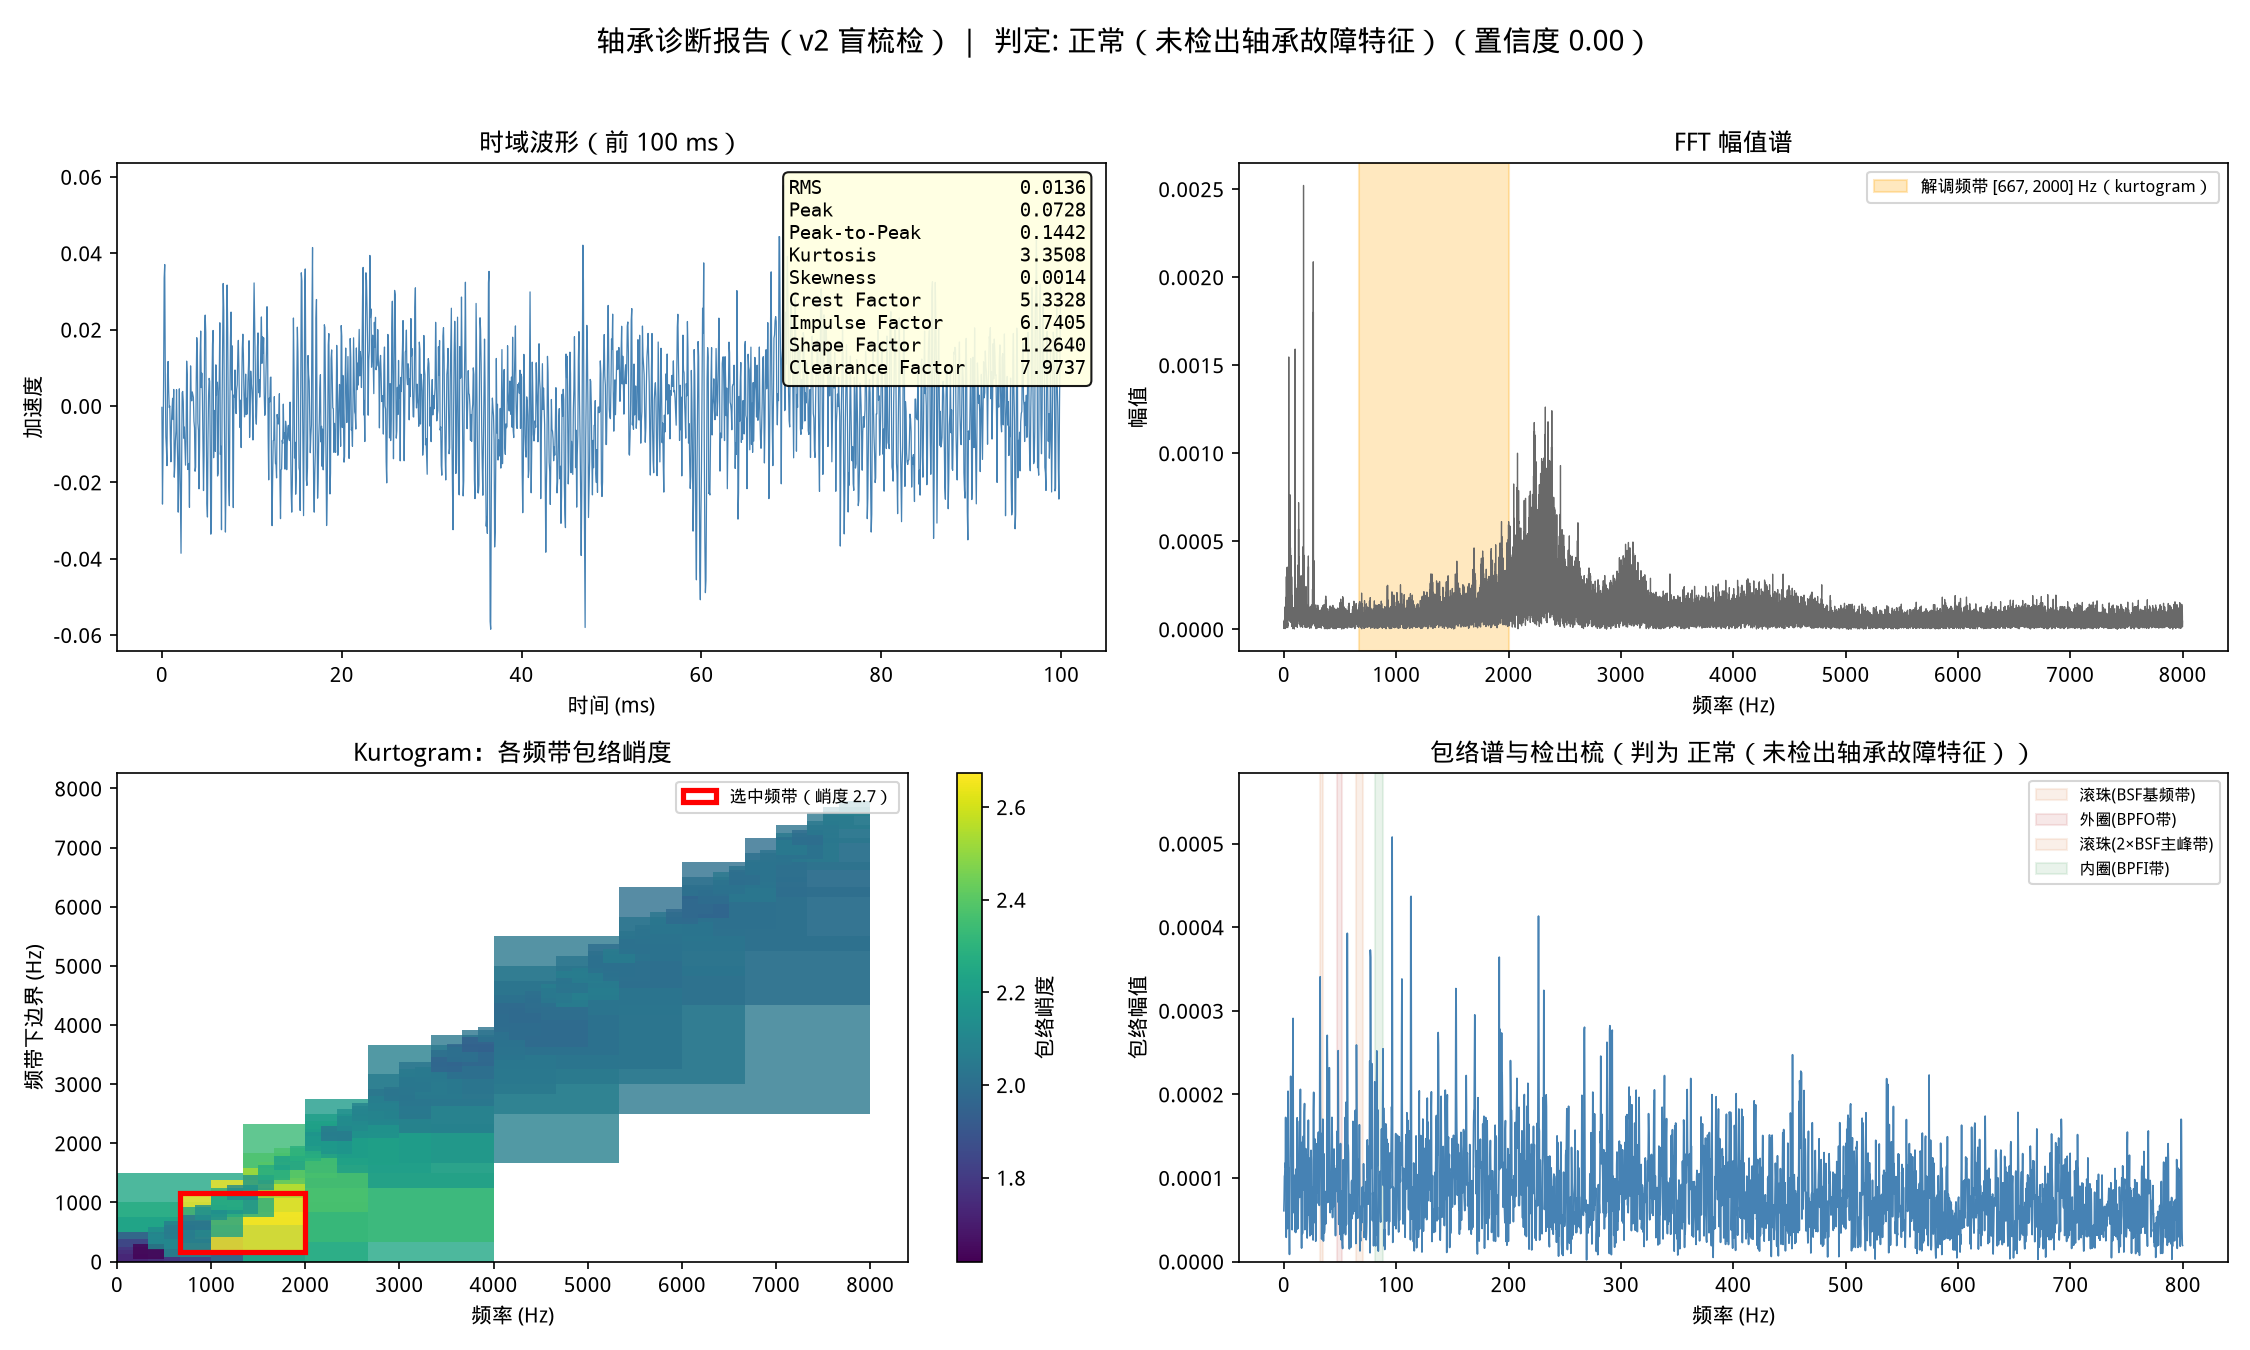


===== 10801 标注=轴承（description=轴承）=====
判决: 滚动体故障（BSF）  置信度 0.33
三类置信度: 外圈=0.109 内圈=0.130 滚珠=0.328  梳确认 A/B/干扰/净 = 2/1/0/1
马氏距离: 1.1（阈值 8.9）→ 触发=False
    梳   68.16 Hz  得分 0.995  命中 5  倒谱 3


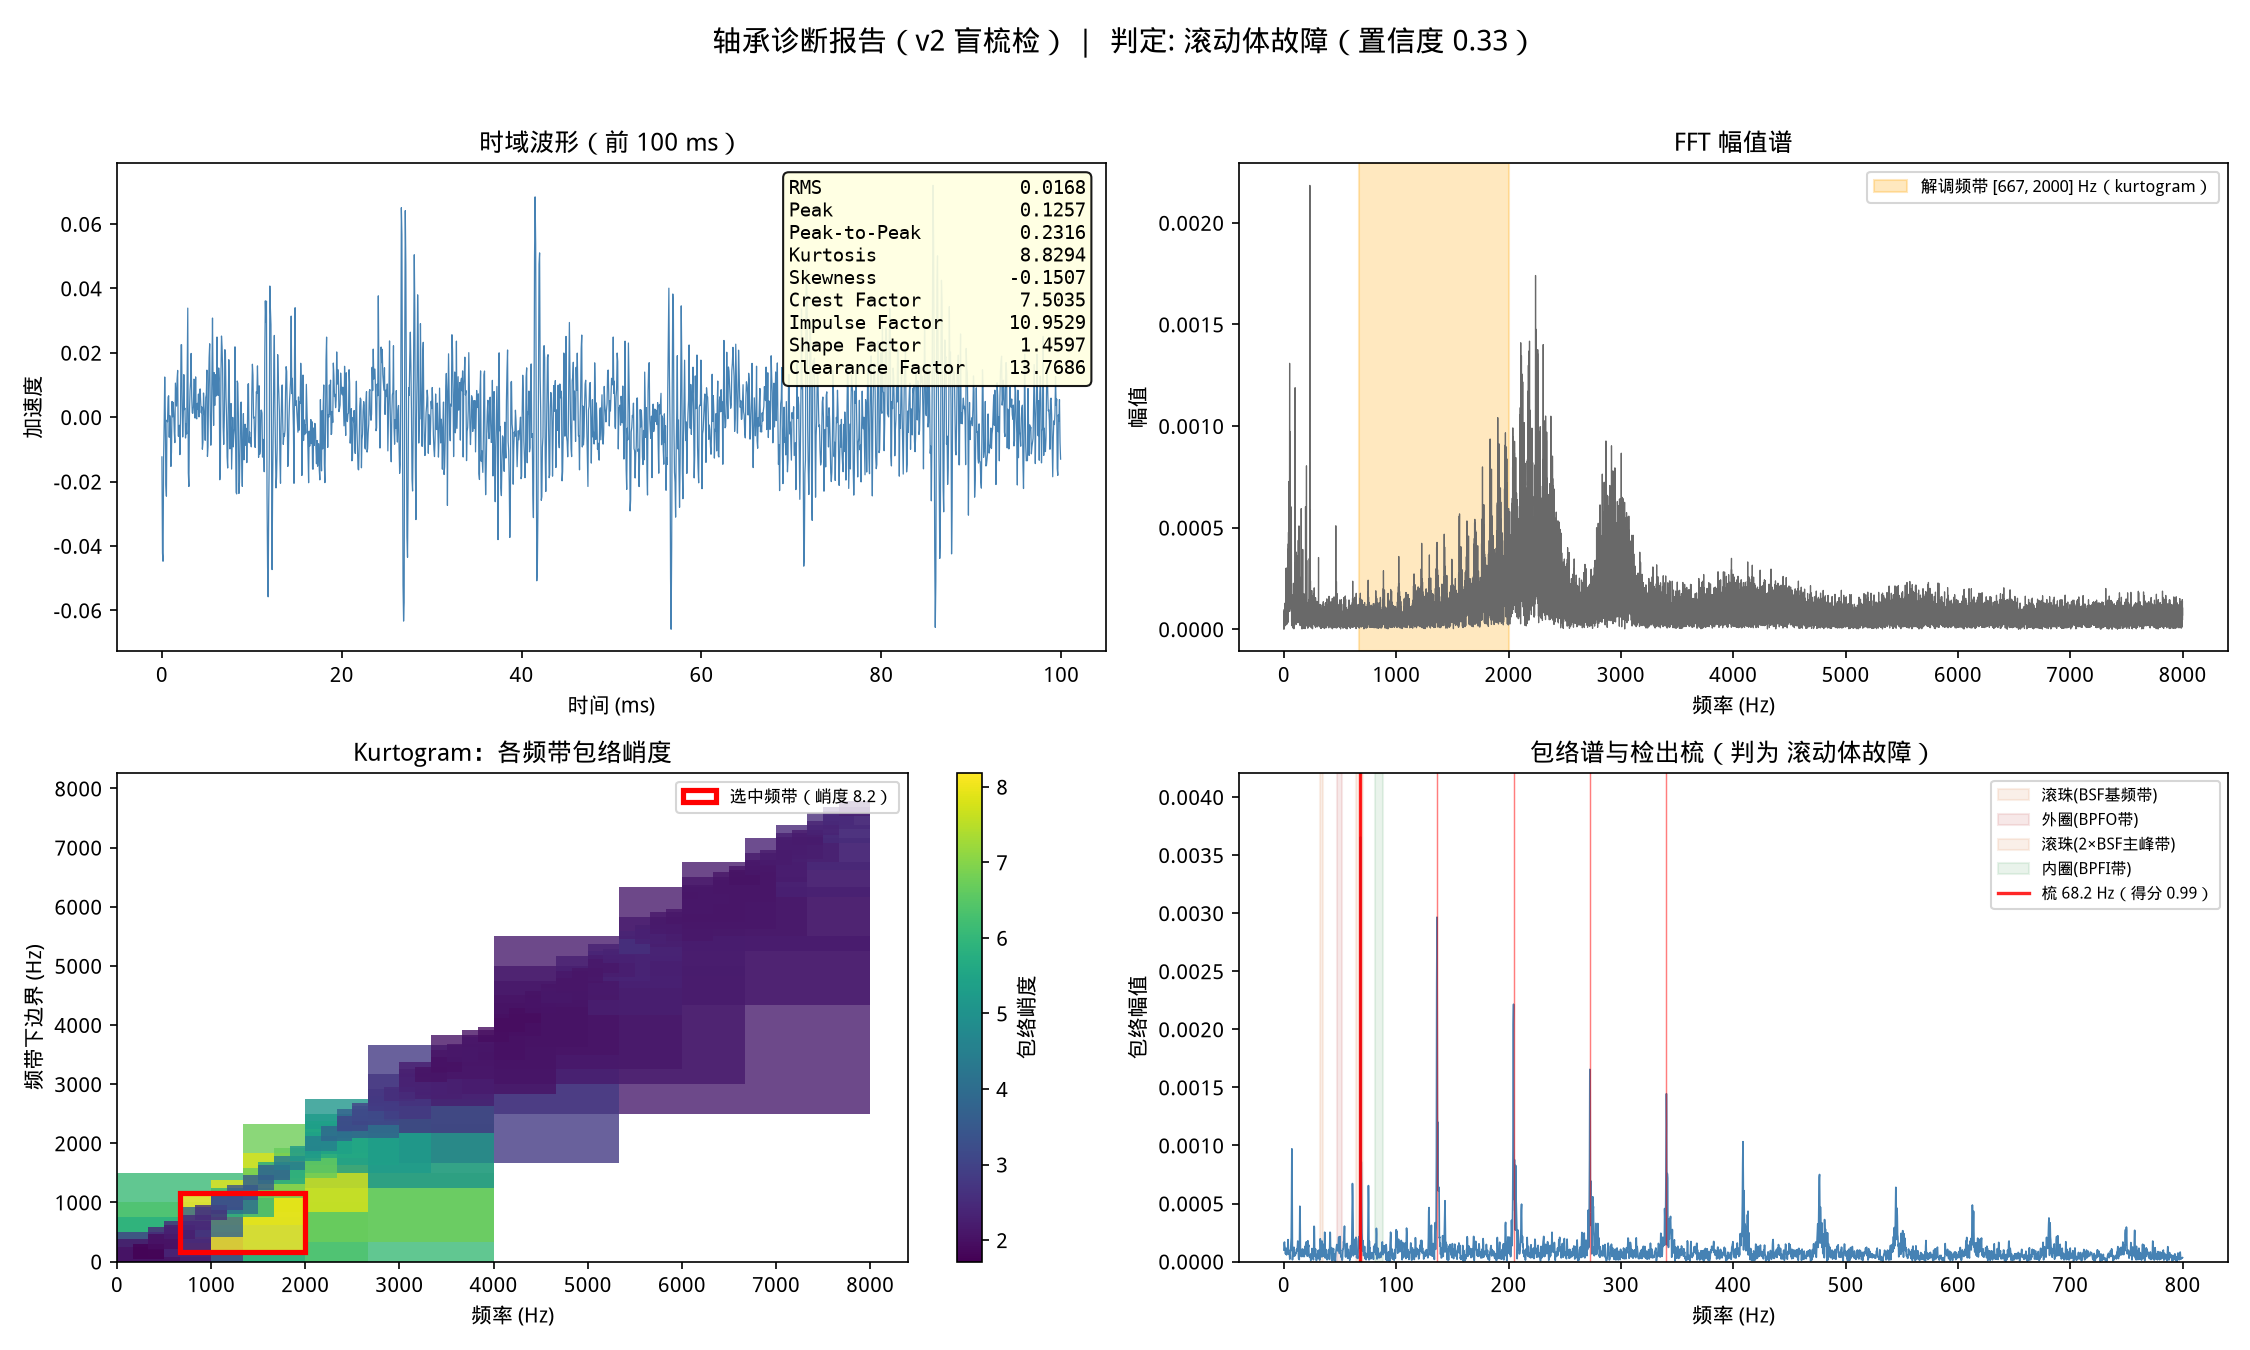


===== 10880 标注=轴承（description=轴承）=====
判决: 内圈故障（BPFI）  置信度 0.68
三类置信度: 外圈=0.045 内圈=0.677 滚珠=0.073  梳确认 A/B/干扰/净 = 1/1/0/1
马氏距离: 0.9（阈值 8.9）→ 触发=False
    梳   79.35 Hz  得分 0.681  命中 5  倒谱 1


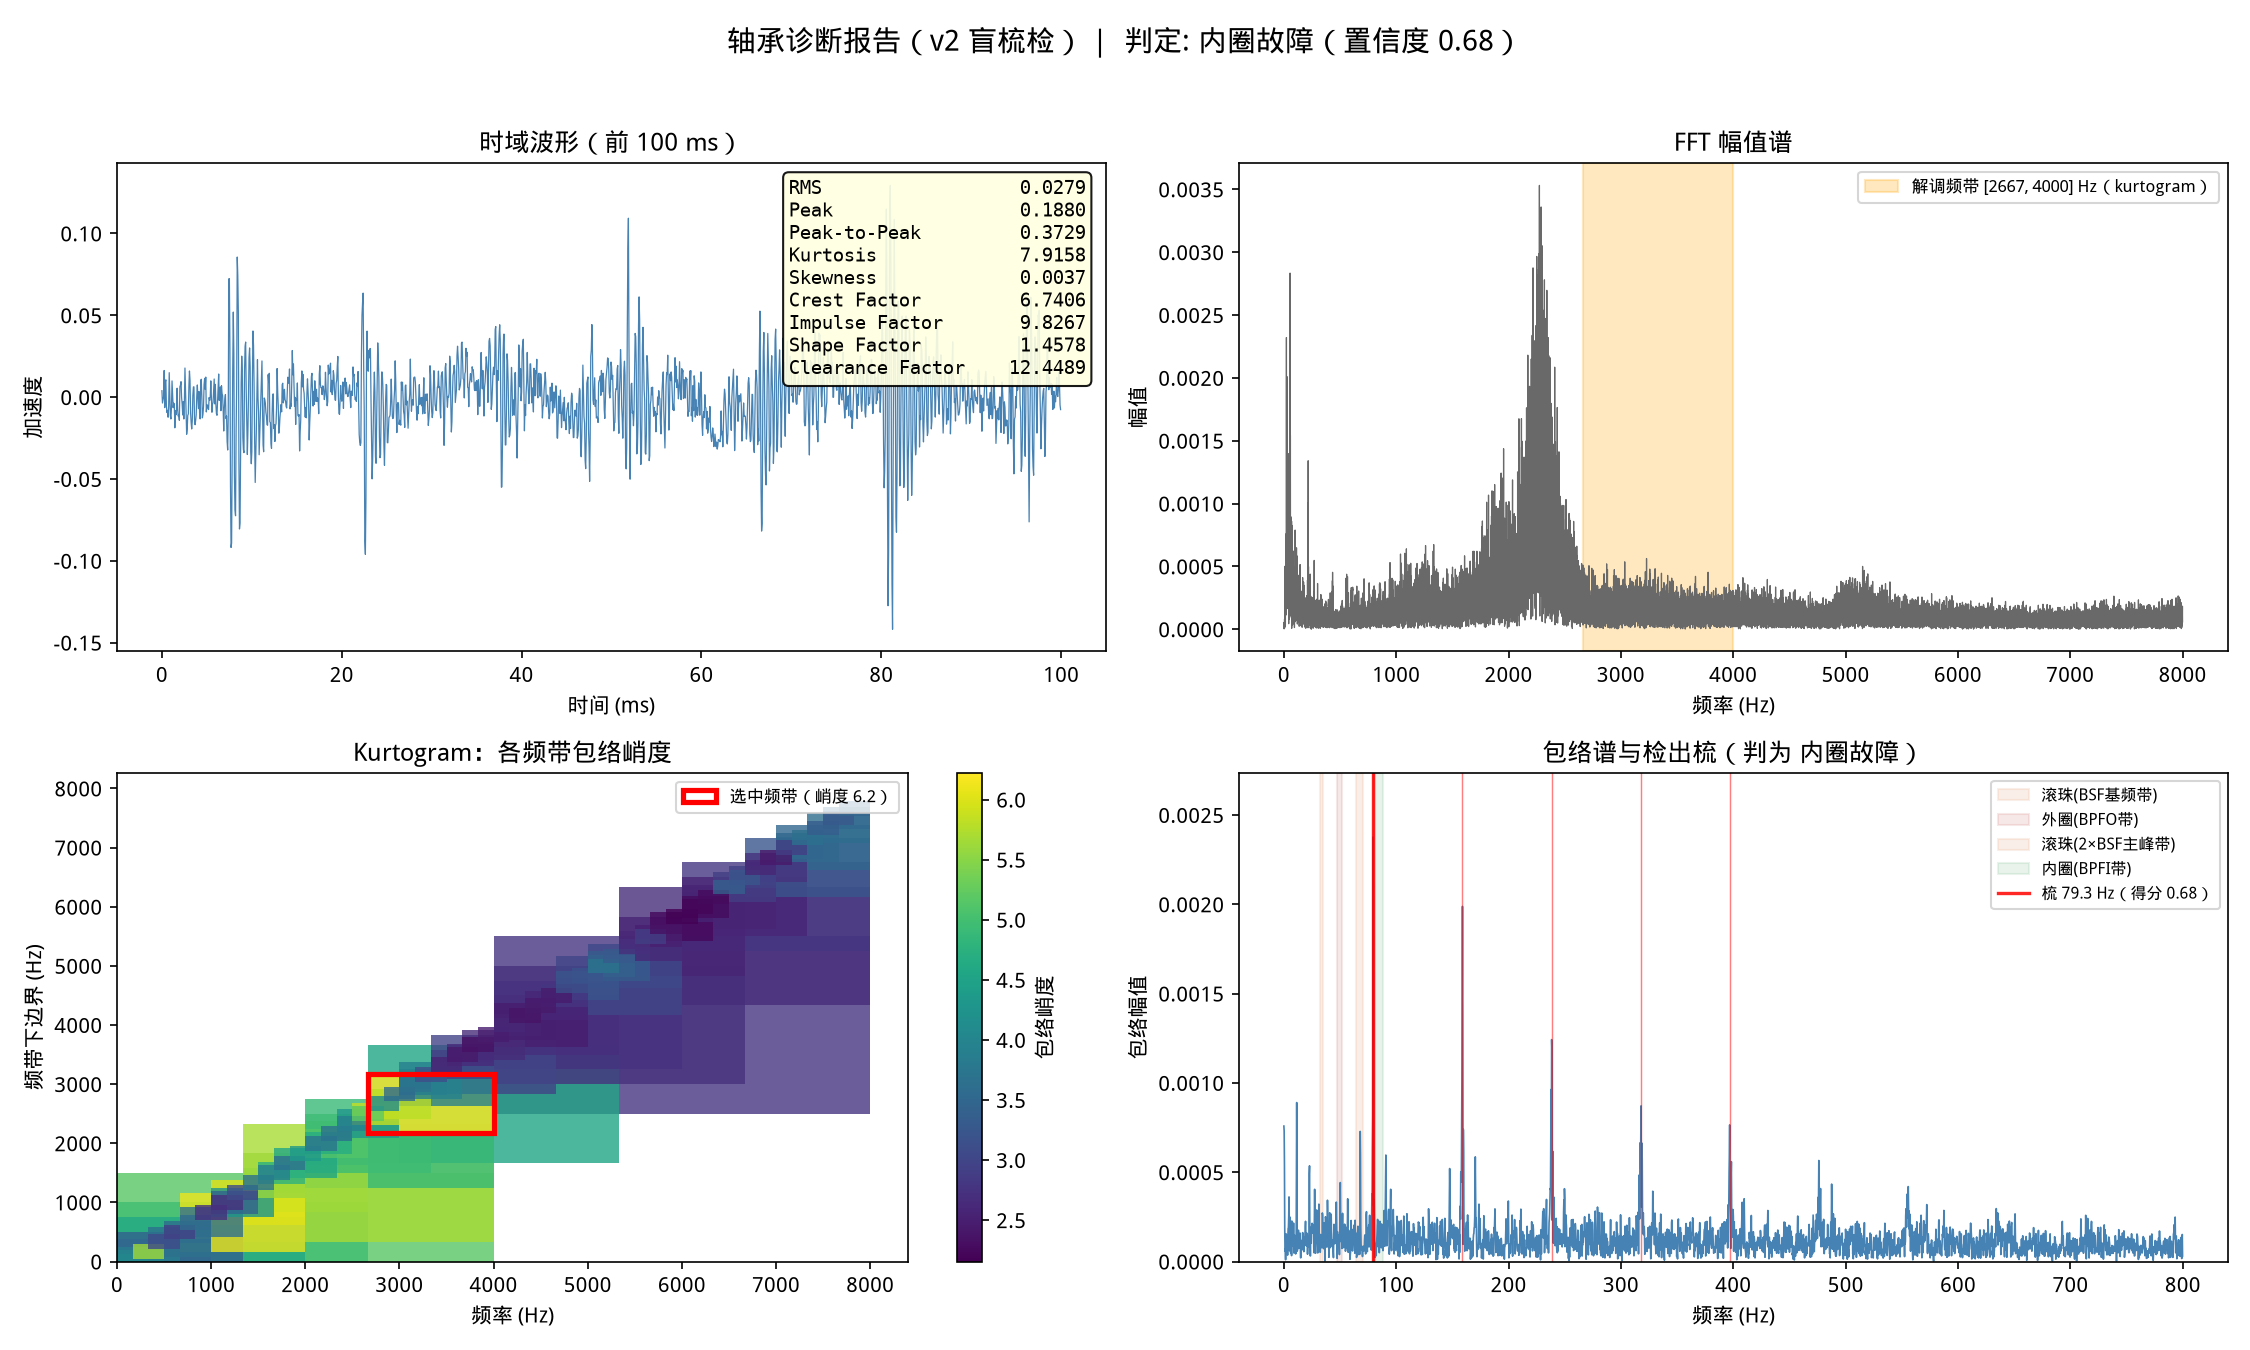


===== 10098 标注=轴承（description=轴承）=====
判决: 异常-轴承（检出故障特征但无法定位部位）（bearing_unlocalized）  置信度 0.00
三类置信度: 外圈=0.000 内圈=0.000 滚珠=0.000  梳确认 A/B/干扰/净 = 1/1/0/1
马氏距离: 5.5（阈值 8.9）→ 触发=False
    梳   22.19 Hz  得分 0.924  命中 5  倒谱 2


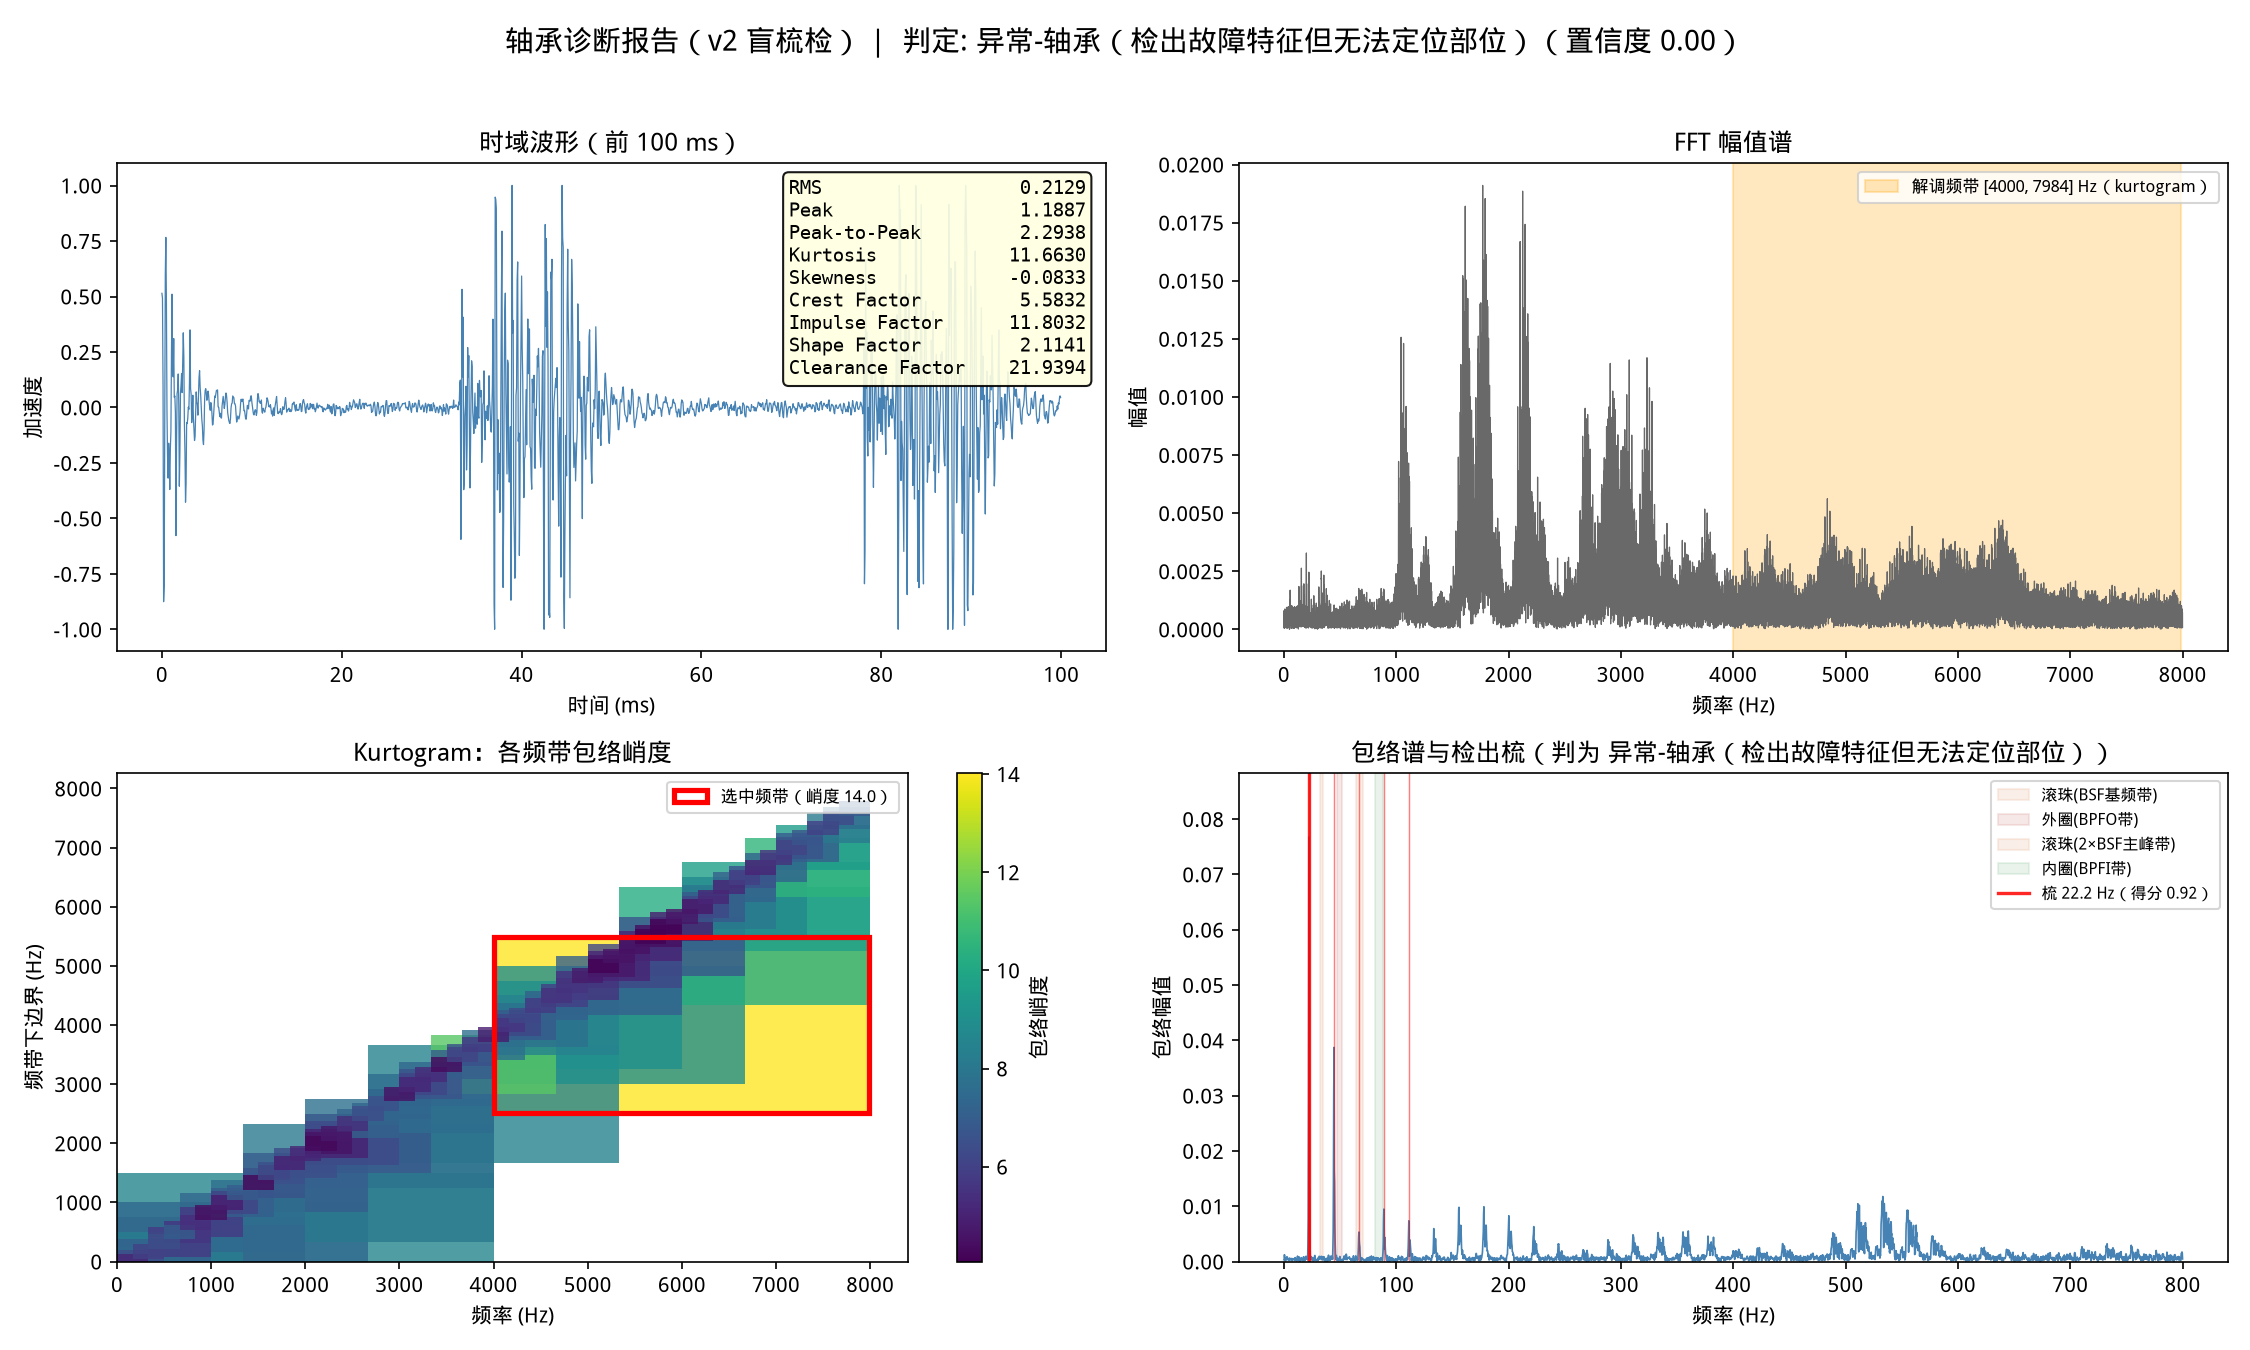


===== 10165 标注=摩擦（description=摩擦）=====
判决: 异常-非轴承（摩擦；无轴承梳特征但马氏距离越限）（friction）  置信度 0.00
三类置信度: 外圈=0.000 内圈=0.000 滚珠=0.000  梳确认 A/B/干扰/净 = 0/0/0/0
马氏距离: 10.1（阈值 8.9）→ 触发=True


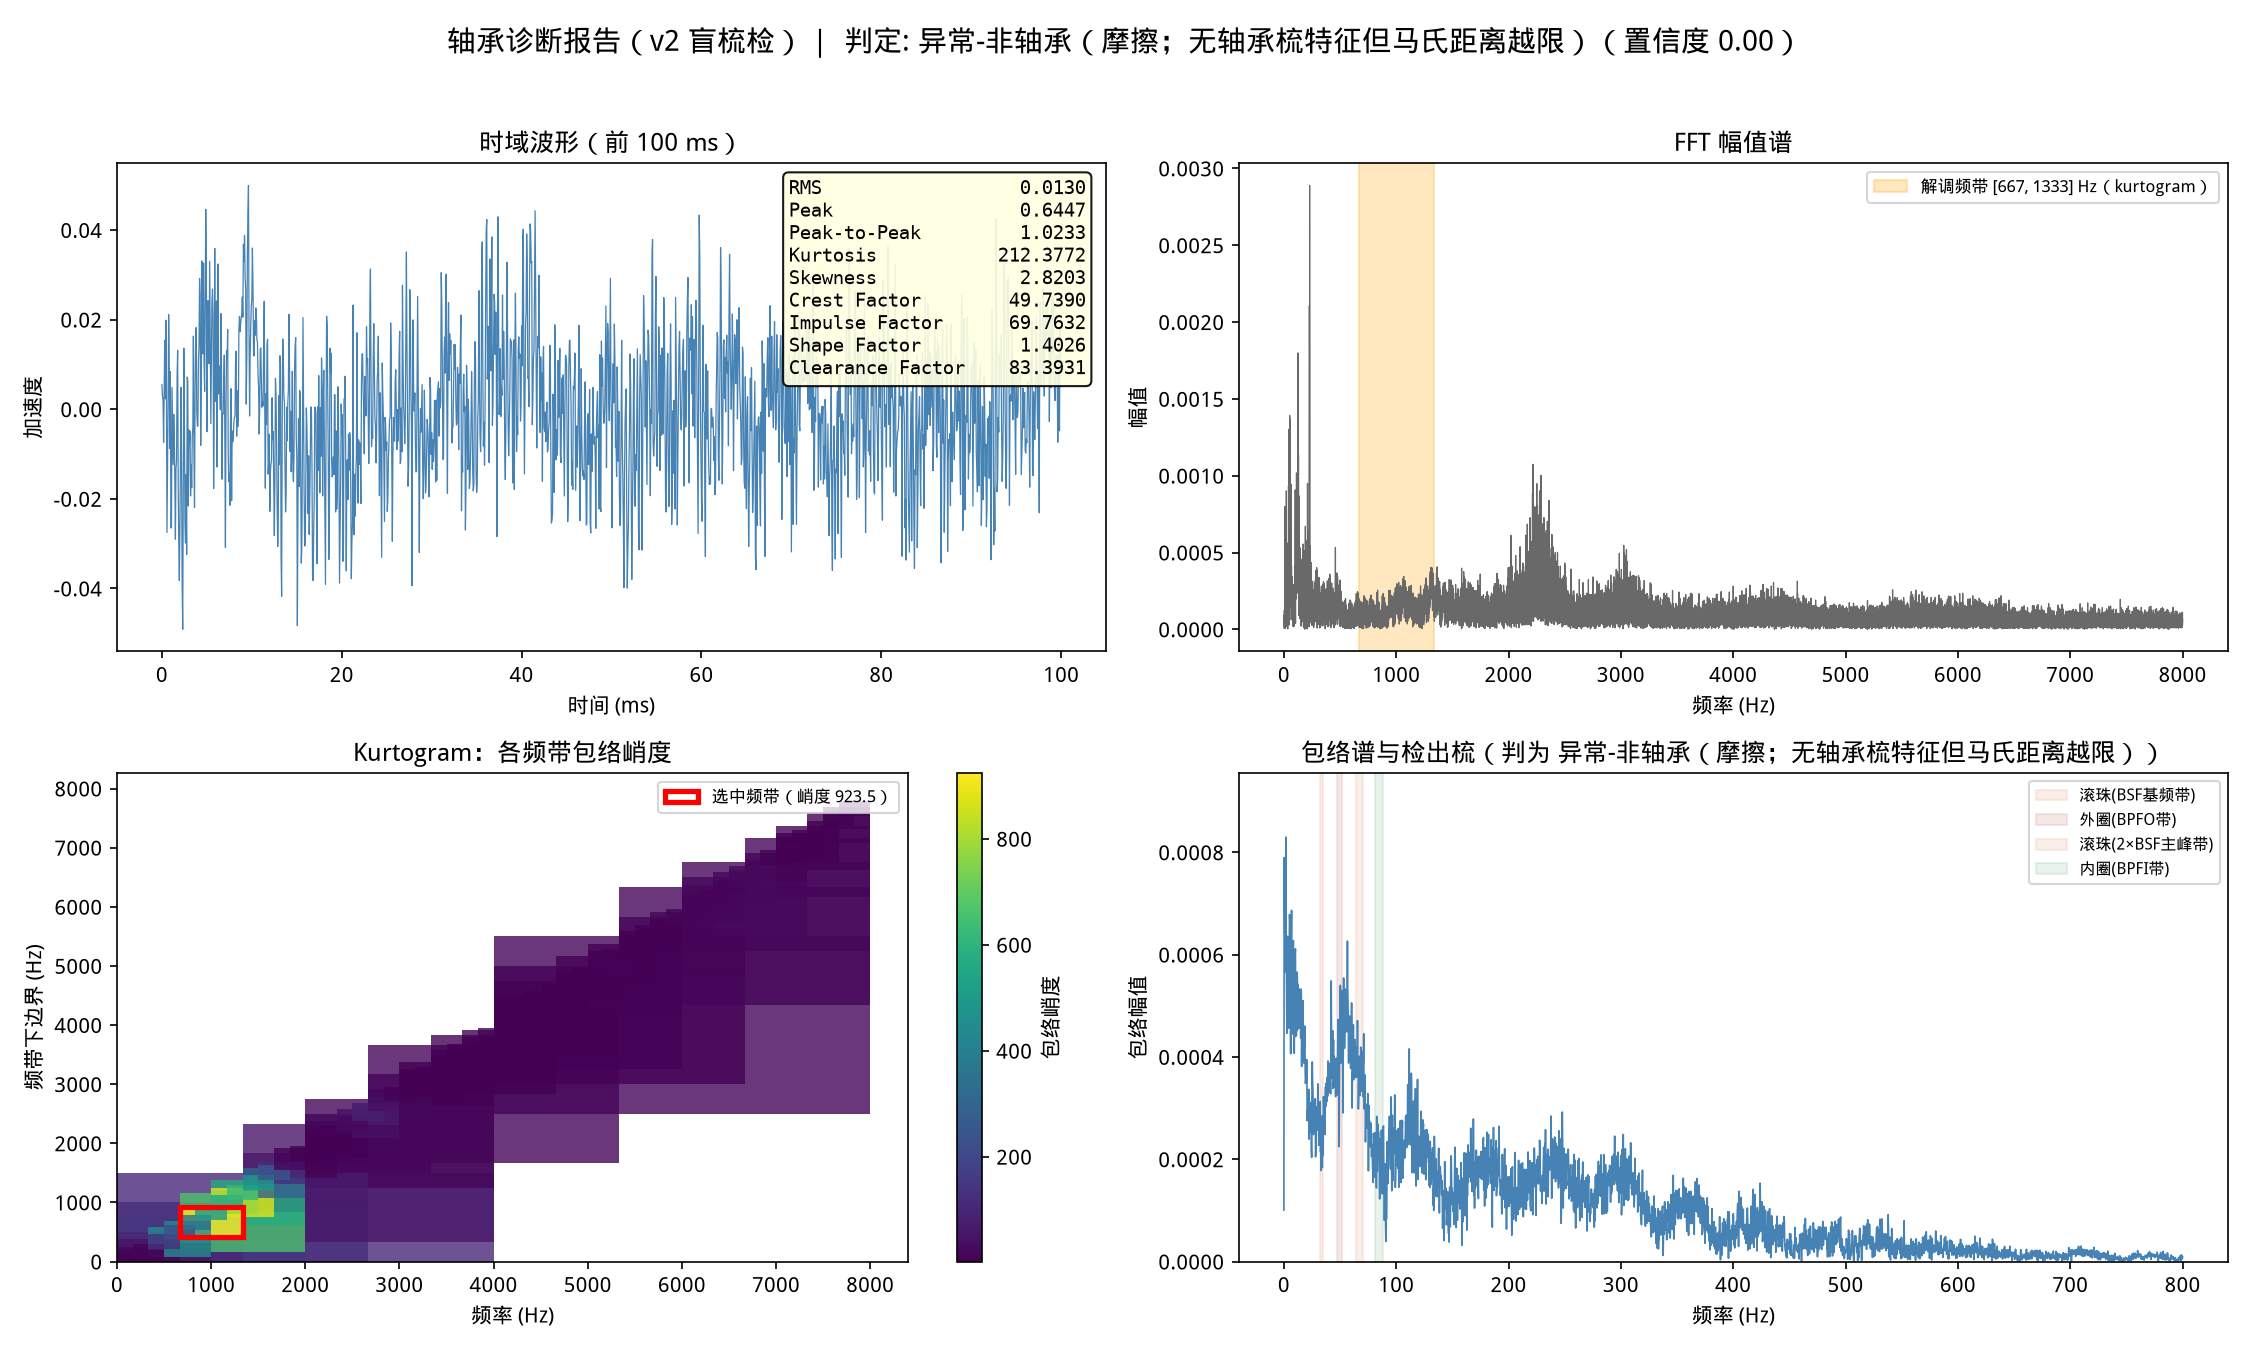

In [13]:
import json
import tempfile
from IPython.display import Image, display
from scipy.io import wavfile
from bearing_unified.report import plot_report

def read_wav_16k(path):
    sr, raw = wavfile.read(path)
    assert sr == 16000, f"{path}: fs={sr}"
    return raw.astype(np.float64) / 32768.0

for r in samples:
    rec = mani[r["id"]]
    xw = read_wav_16k(rec["storage_path"])
    res = diagnose(xw, fs=FS, bearing=F7, calibrator=BL, maha_threshold=THR)
    print(f"\n===== {r['id']} 标注={r['subset']}（description={rec['description']}）=====")
    print(f"判决: {res.verdict_cn}（{res.verdict}）  置信度 {res.confidence:.2f}")
    print(f"三类置信度: 外圈={res.conf_outer:.3f} 内圈={res.conf_inner:.3f} 滚珠={res.conf_ball:.3f}  "
          f"梳确认 A/B/干扰/净 = {res.comb_confirmed}/{res.cepstrum_confirmed}/{res.n_interference}/{res.n_clean_combs}")
    if res.maha_dist is not None:
        print(f"马氏距离: {res.maha_dist:.1f}（阈值 {THR:.1f}）→ 触发={res.trigger}")
    if res.combs:
        for c in res.combs:
            mark = f"（干扰:{c['guard_reason']}）" if c["suspected_interference"] else ""
            print(f"    梳 {c['f0']:7.2f} Hz  得分 {c['score']:.3f}  命中 {c['hits']}  倒谱 {c['cep_hits']}{mark}")
    with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as fp:
        plot_report(res, fp.name)
        display(Image(filename=fp.name))

### 2.2 批量结论（引用 1349 条正式验收数字）

正式验收（`analysis/run_eval_unified.py`，统一包引擎、同一口径）的汇总指标，
直接从验收产物 `eval_detail.json` 读取——notebook 不现场重跑千条。

In [14]:
detail = json.loads((ROOT / "analysis" / "reports" / "audio_assets" / "unified" / "eval_detail.json").read_text(encoding="utf-8"))
na, bf = detail["normal_abnormal_v2"], detail["bearing_friction_v2"]
print("== 1349 条验收关键指标（统一包） ==")
print(f"正常误报率      : {na['正常误报率']:.1%}（{na['fp']}/{na['fp'] + na['tn']}，门槛 ≤2.1%）")
print(f"异常检出率      : {na['异常检出率']:.1%}（{na['tp']}/{na['tp'] + na['fn']}）")
b = bf["bearing"]
print(f"轴承全体口径检出: {b['全体口径检出率_含未定位']:.1%}（仅定位 {b['全体口径检出率_仅定位']:.1%}，门槛 ≥48.8%）")
print(f"轴承未定位      : {b['crosstab']['轴承-未定位']}/{b['n']}（原型 v2 为 45/168，门槛：显著更低）")
f = bf["friction"]
print(f"摩擦全体口径检出: {f['全体口径检出率_仅定位']:.1%}（门槛 ≥15.5%——未达标，归因见验收报告）")
print(f"检出驱动分解    : 梳证据 {na['tp_梳驱动']} / 马氏兜底 {na['tp_马氏兜底']}")
print(f"干扰防护        : 标记 {sum(detail['v2']['guard_reasons'].values())} 个梳，明细 {detail['v2']['guard_reasons']}")

== 1349 条验收关键指标（统一包） ==
正常误报率      : 2.1%（12/566，门槛 ≤2.1%）
异常检出率      : 32.3%（253/783）
轴承全体口径检出: 48.8%（仅定位 27.4%，门槛 ≥48.8%）
轴承未定位      : 36/168（原型 v2 为 45/168，门槛：显著更低）
摩擦全体口径检出: 13.8%（门槛 ≥15.5%——未达标，归因见验收报告）
检出驱动分解    : 梳证据 190 / 马氏兜底 63
干扰防护        : 标记 49 个梳，明细 {'低频梳(f0<20Hz,疑轴频族)': 38, '工频50Hz': 5, '轴频谐波2×19.167Hz': 4, '轴频谐波4×19.167Hz': 2}


## 3. 延伸阅读

- `bearing_unified_method/docs/principles.md`——方法原理（13 章：v2 盲梳检
  与频带落入定位的原理、转速先验降级、ML 与新奇检测后端）；
- `bearing_unified_method/docs/design.md`——设计决策 D1–D22（每条含"为什么"
  与否决依据）；
- `analysis/reports/unified_acceptance/统一包验收报告.md`——正式验收复测
  （1349 + 81 条）的门槛逐项对照与归因；
- `merged_proposal/双方案优缺点汇总与合并建议.md`——合并方案评审稿；
- 评测脚本：`analysis/run_eval_unified.py`（1349 条）与
  `analysis/run_eval_unified_4class.py`（81 条），均可用 `--smoke` 快速验证。